In [1]:
import sys
import os

# Ruta ubicacion scripts mhw
ruta_mhw = os.path.abspath(os.path.join('..', 'mhw'))

# Agregamos la ruta al sistema
if ruta_mhw not in sys.path:
    sys.path.append(ruta_mhw)

import warnings
# Ignora warnings especificamente de numpy y la existencia de arrays con nans
#warnings.filterwarnings("ignore", message="All-NaN slice encountered")

%load_ext autoreload
%autoreload 2

In [17]:
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
from matplotlib.pyplot import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.crs import PlateCarree
from cartopy.feature import LAND, COASTLINE, RIVERS
from cmocean.cm import haline, thermal

In [3]:
import numpy as np
import xarray as xr
from scipy import stats

import datasets_utils as dsu
import mhw_core as mhw
import time_utils as timeu

nf_waves = "pcaso_waves.nc"
nf_df_waves = "pcaso_df_waves.csv"

In [24]:
def trend_matrix_xarray(
    da: xr.DataArray, time_dim: str = "time"
) -> tuple[xr.DataArray, xr.DataArray, xr.DataArray]:
    """Calcula la tendencia lineal (slope, p-value, intercept) de forma eficiente

    aprovechando la vectorización nativa de Xarray.
    """

    # 1. Definimos la función interna que operará sobre el vector temporal de cada píxel
    def _pixel_trend(y, x):
        # Si todo es NaN (tierra) o no hay suficientes datos para una regresión
        y_nans = np.isnan(y)
        if y_nans.all() or np.sum(~y_nans) < 3:
            return np.nan, np.nan, np.nan
        y = y[~y_nans]
        x = x[~y_nans]
        x = x - np.nanmean(x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        return slope, p_value, intercept
    
    # 2. apply_ufunc se encarga de aplicar la función vectorialmente en la grilla
    trend, trend_pvalue, trend_intercept = xr.apply_ufunc(
        _pixel_trend,
        da,
        da.year.values,
        input_core_dims=[[time_dim], [time_dim]],  # Dimensión sobre la cual se aplica (tiempo)
        output_core_dims=[[], [], []],  # Salidas escalares por píxel
        vectorize=True,  # Ejecuta el bucle interno optimizado en NumPy
    )

    return trend, trend_pvalue, trend_intercept



In [6]:
ds_anual = xr.open_dataset(dsu.join_path(dsu.DIR_DATASETS, "pcaso_anual_stats.nc"))

In [29]:
ds_anual

<xarray.Dataset>
Dimensions:                (year: 44, lat: 87, lon: 83)
Coordinates:
  * year                   (year) int64 1981 1982 1983 1984 ... 2022 2023 2024
  * lat                    (lat) float64 -54.88 -54.62 -54.38 ... -33.62 -33.38
  * lon                    (lon) float64 290.1 290.4 290.6 ... 310.1 310.4 310.6
Data variables:
    duration               (year, lat, lon) float64 ...
    total_events           (year, lat, lon) float64 ...
    anom_max               (year, lat, lon) float64 ...
    mean_of_max_anomalies  (year, lat, lon) float64 ...
    mean_of_min_anomalies  (year, lat, lon) float64 ...

In [30]:
trend, pvalue, intercept = trend_matrix_xarray(ds_anual.duration, time_dim="year")

In [31]:
is_significative = np.where(pvalue.values < .1, 1, np.nan)

In [32]:
trend.values[~np.isnan(trend.values)]

array([0.27521123, 0.19244504, 0.32525548, ..., 0.23755049, 0.20961341,
       0.22563426])

Text(0.5, 0, '$\\frac{events}{year}$')

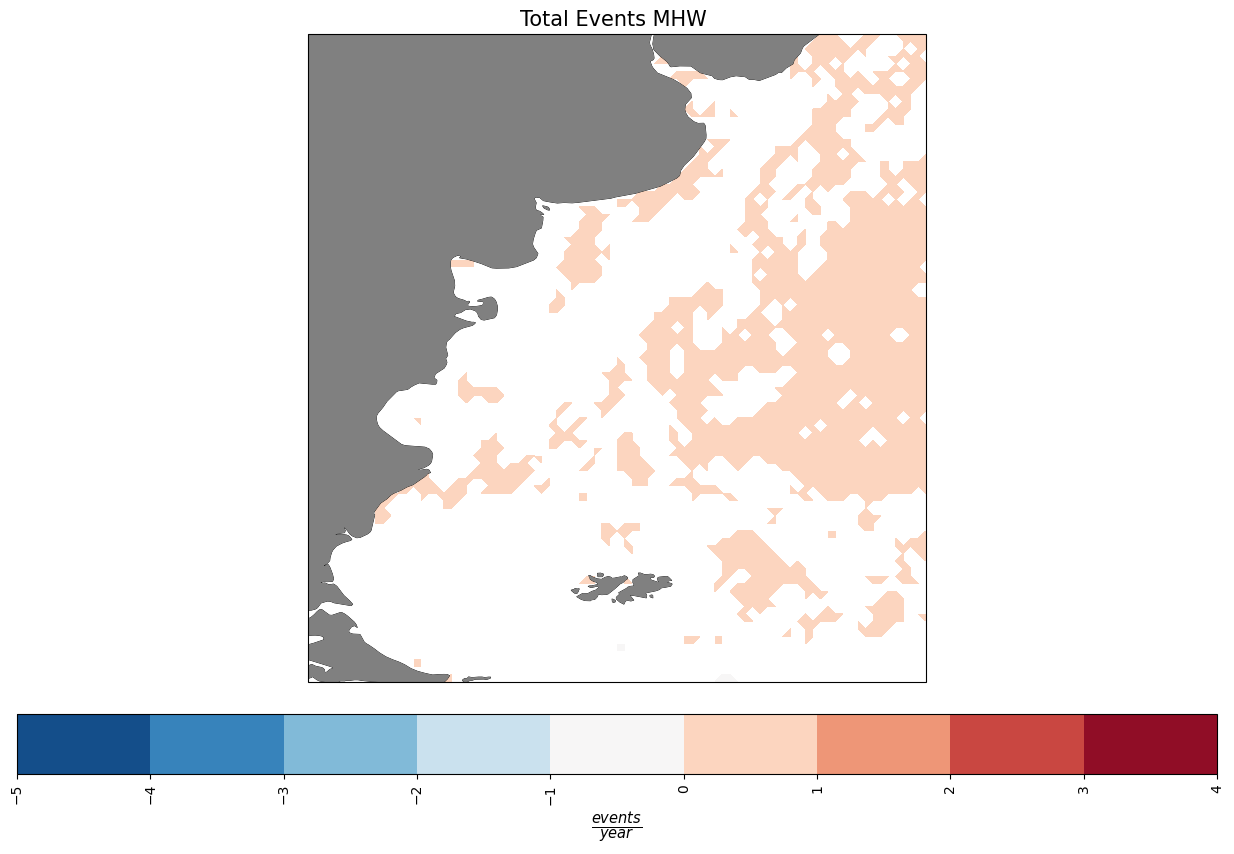

In [35]:
shrink = 1
pad = 0.04
color = "k"


fig = plt.figure(figsize=(12, 8))
ax0 = fig.add_axes([0, 0., 1, 1], projection=PlateCarree()) 

ax0.set_facecolor('white')
ax0.add_feature(LAND, facecolor="gray", zorder=2)
ax0.add_feature(COASTLINE, linewidth=0.5)
ax0.set_title("Total Events MHW ", size=15)

#im = ax0.contourf(ds_anual.lon - 360, ds_anual.lat, ds_anual.duration_count.sum(axis=0, skipna=True),levels=np.arange(60, 120, 0.01), cmap="OrRd",  zorder=0)
levels = np.arange(-5, 5, 1)
ticks=levels
im = ax0.contourf(ds_anual.lon - 360, ds_anual.lat, trend * is_significative, levels=levels, cmap="RdBu_r", zorder=0)
clb = plt.colorbar(im, ticks=ticks, shrink=shrink, pad=pad , extend='both', drawedges=False, orientation="horizontal")
clb.set_label("Events/Decade", size=18)
clb.ax.tick_params(rotation=90)
clb.ax.set_xlabel(r"$\frac{events}{year}$", size=15)

In [189]:
ds_anual.duration_count.sum(axis=0, skipna=True)

<xarray.DataArray 'duration_count' (lat: 87, lon: 83)>
array([[  0.,   0.,   0., ..., 109., 105., 108.],
       [  0.,   0.,   0., ..., 102.,  96., 108.],
       [  0.,   0.,   0., ..., 108., 102., 113.],
       ...,
       [  0.,   0.,   0., ...,  68.,  78.,  83.],
       [  0.,   0.,   0., ...,  74.,  80.,  82.],
       [  0.,   0.,   0., ...,  83.,  80.,  78.]])
Coordinates:
  * lat      (lat) float64 -54.88 -54.62 -54.38 -54.12 ... -33.88 -33.62 -33.38
  * lon      (lon) float64 290.1 290.4 290.6 290.9 ... 309.9 310.1 310.4 310.6